In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

for dirname, _, filenames in os.walk("../data/raw"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/raw\books.csv


In [10]:
df = pd.read_csv("../data/raw/books.csv", on_bad_lines="skip")
df.index = df["bookID"]

In [21]:
df["num_pages"]=df["  num_pages"]

In [11]:
df.shape[0]

11123

In [12]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,,,
1,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
2,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
4,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
5,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
8,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [13]:
df.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

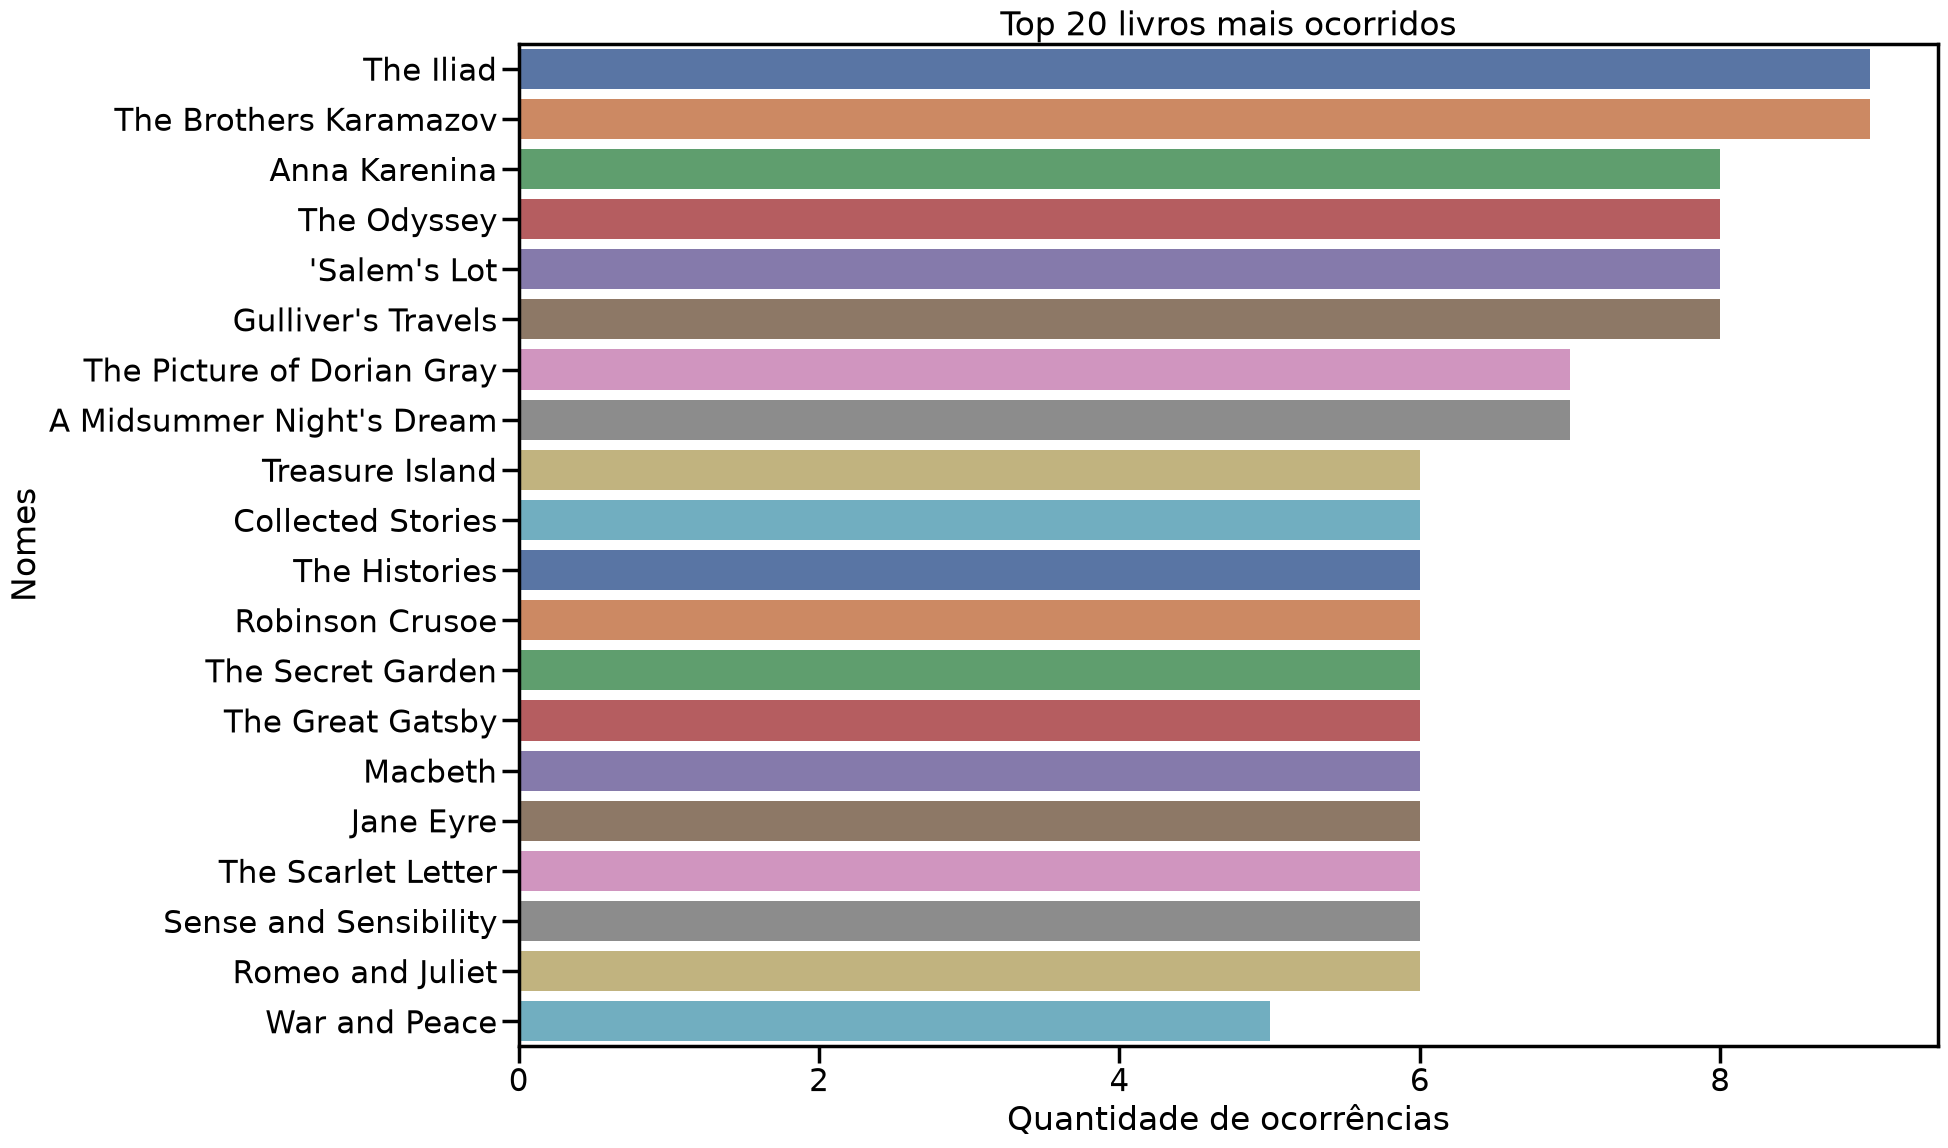

In [14]:
top_titles = df["title"].value_counts()[:20]
sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    x=top_titles.values, y=top_titles.index, palette="deep", hue=top_titles.index
)
plt.title("Top 20 livros mais ocorridos")
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Nomes")
plt.tight_layout()
plt.show()

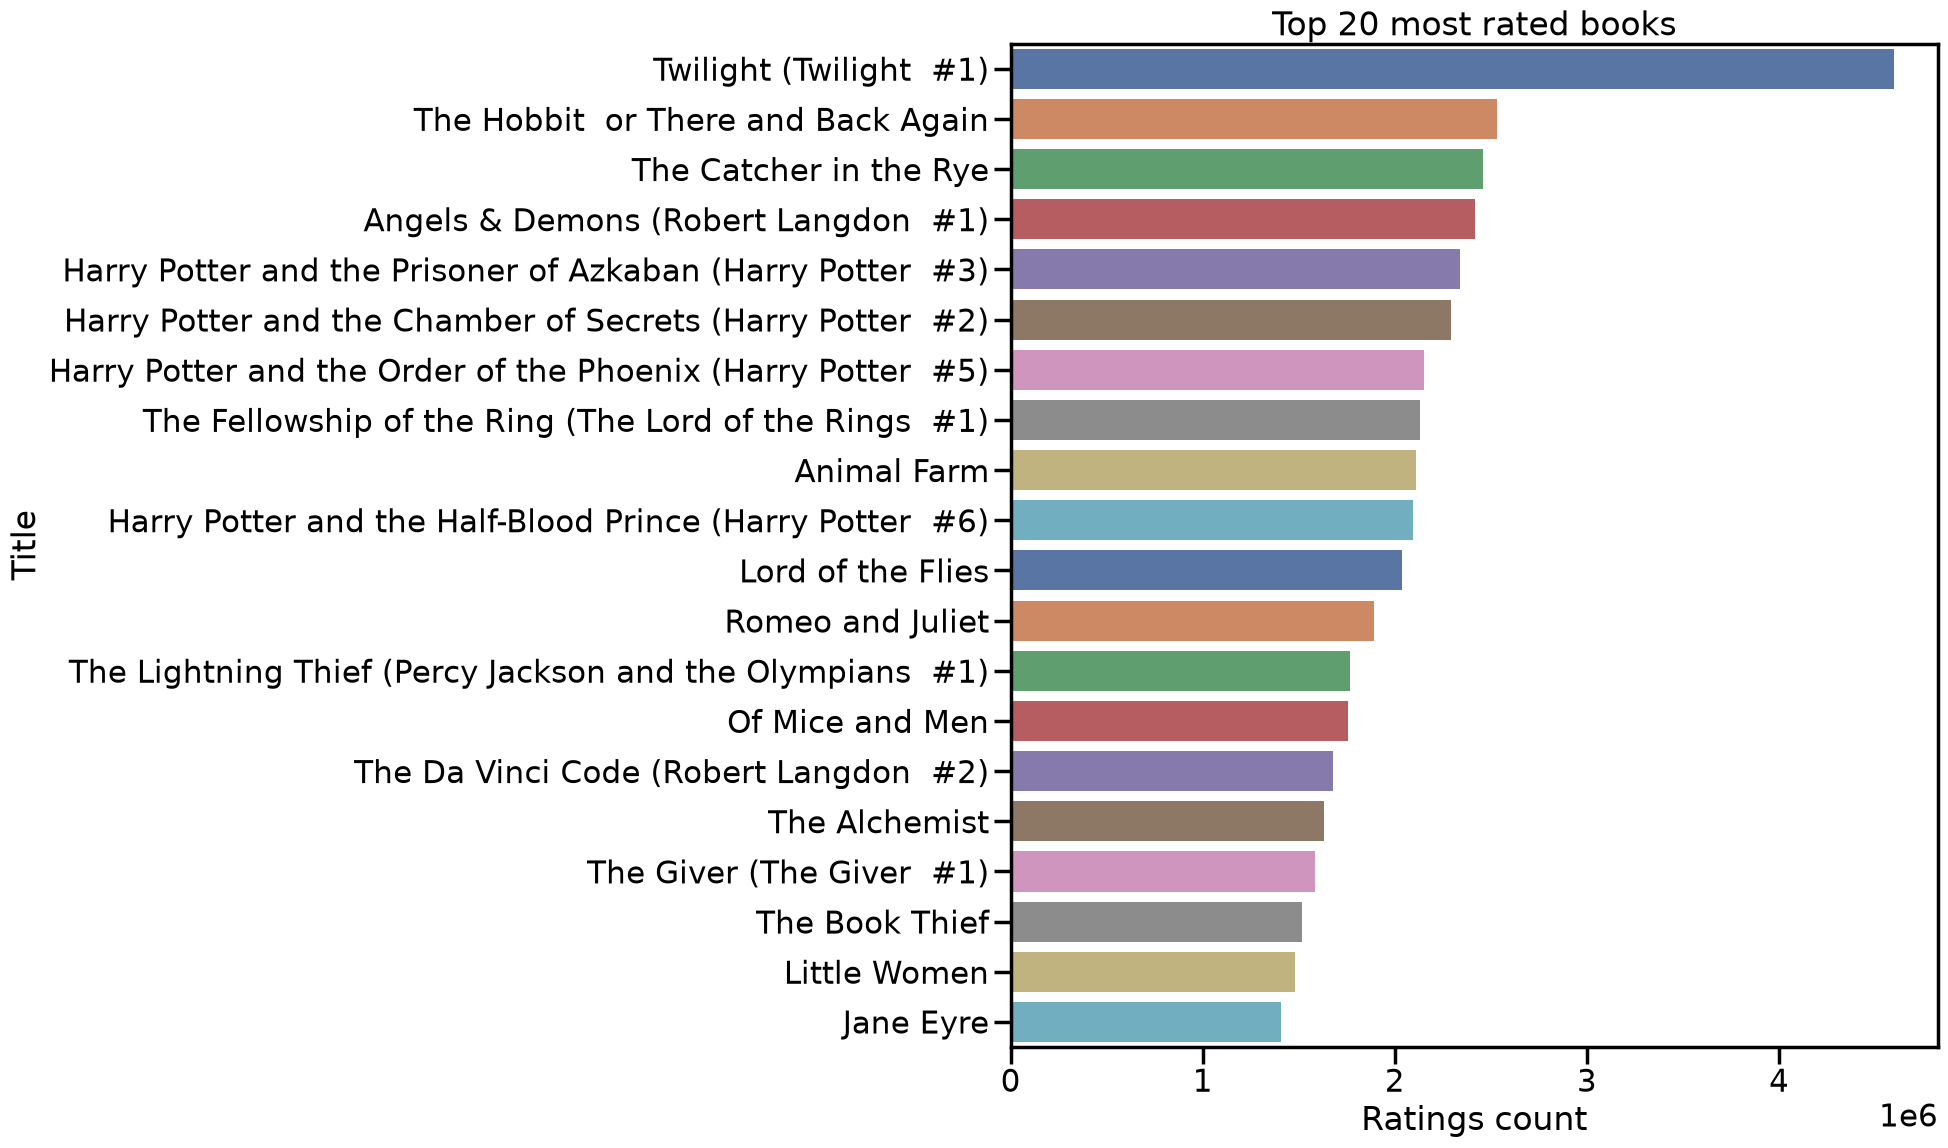

In [15]:
top_rated = df.nlargest(20, "ratings_count")

sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    x=top_rated["ratings_count"].values,
    y=top_rated["title"].values,
    palette="deep",
    hue=top_rated["title"].values,
)
plt.title("Top 20 most rated books")
plt.xlabel("Ratings count")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

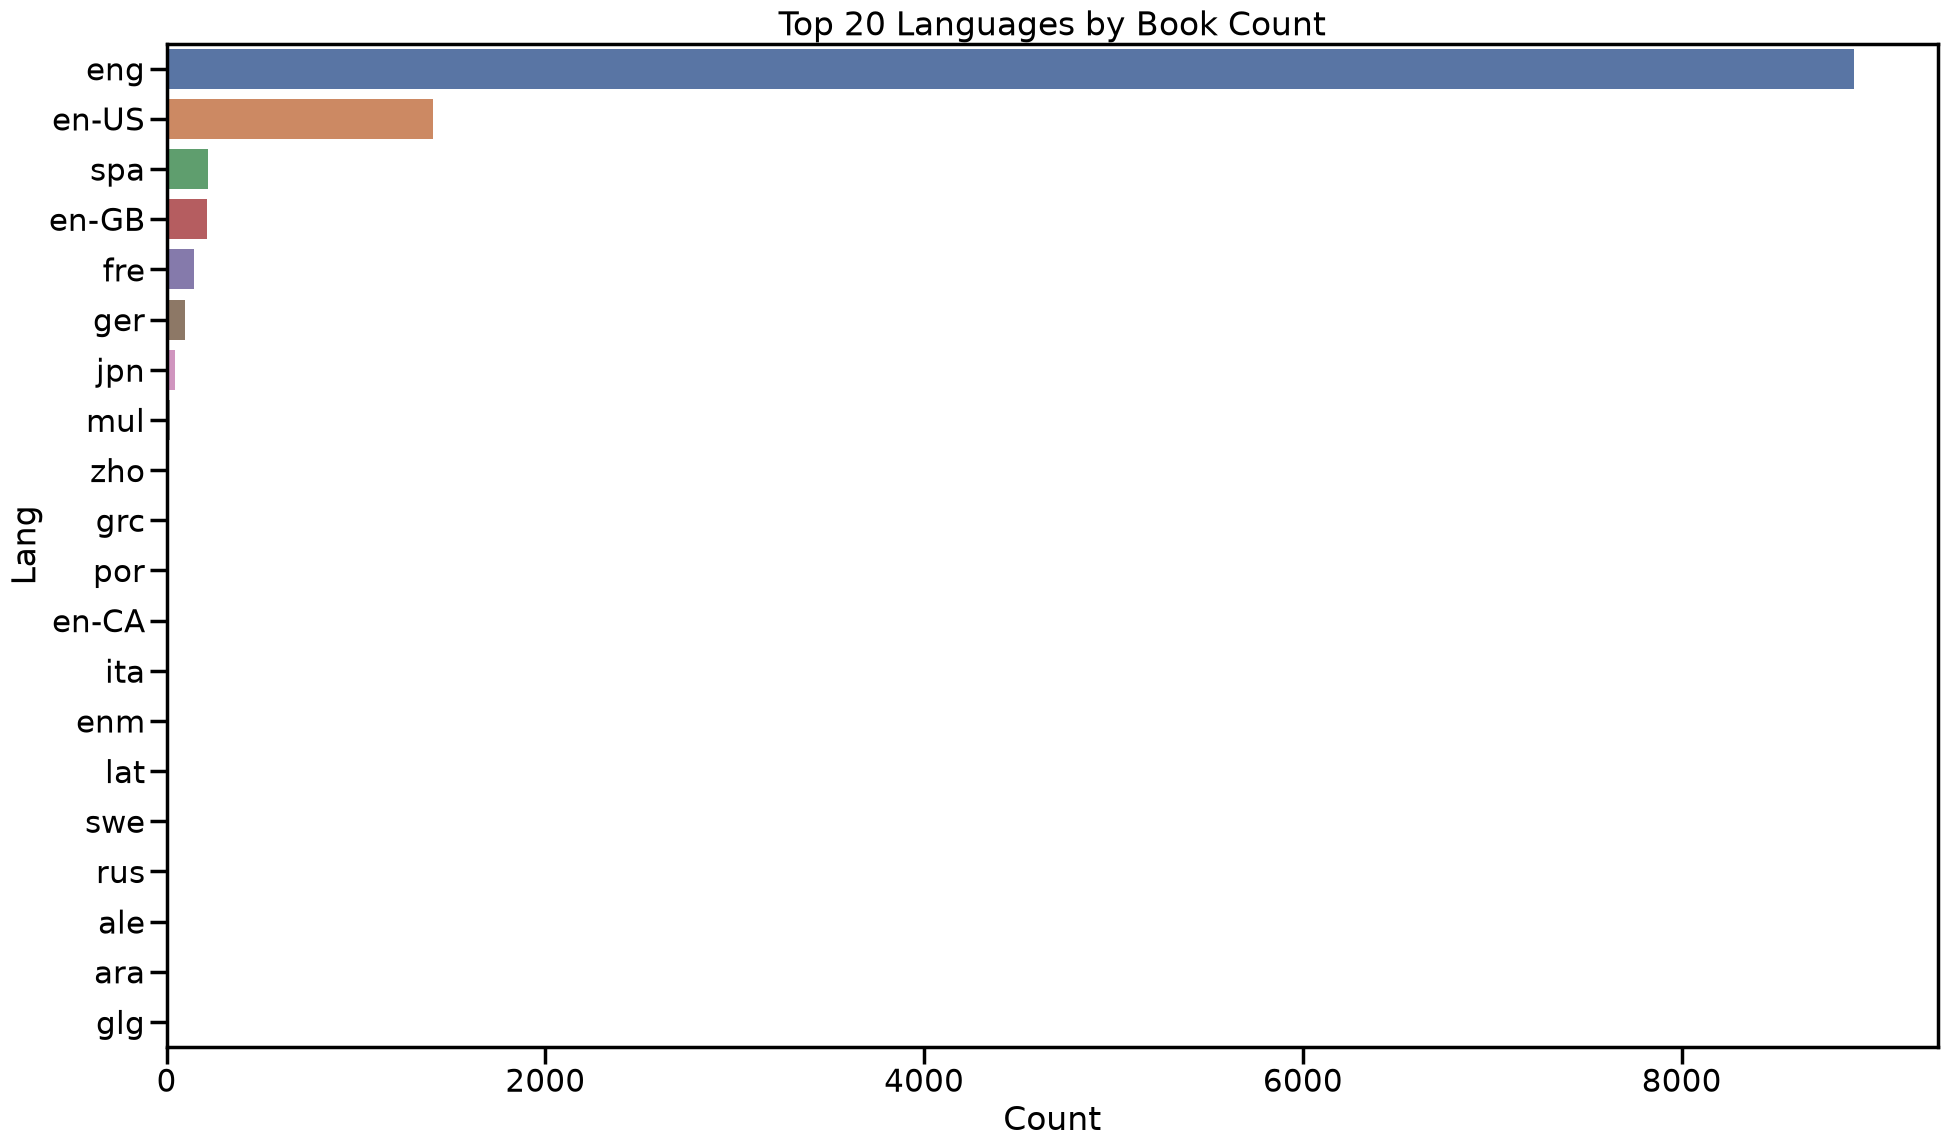

In [16]:
top_lang = df.groupby("language_code").size().sort_values(ascending=False)[:20]
sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    x=top_lang.values,
    y=top_lang.index,
    palette="deep",
    hue=top_lang.index,
    legend=False,
)
plt.title("Top 20 Languages by Book Count")
plt.xlabel("Count")
plt.ylabel("Lang")
plt.tight_layout()
plt.show()

In [17]:
C = (df["average_rating"] * df["ratings_count"]).sum() / df["ratings_count"].sum()
m = df["ratings_count"].quantile(0.50)
df["bayesian_avg"] = (df["ratings_count"] / (df["ratings_count"] + m)) * df[
    "average_rating"
] + (m / (df["ratings_count"] + m)) * C

top_books = df.sort_values("bayesian_avg", ascending=False).head(20)

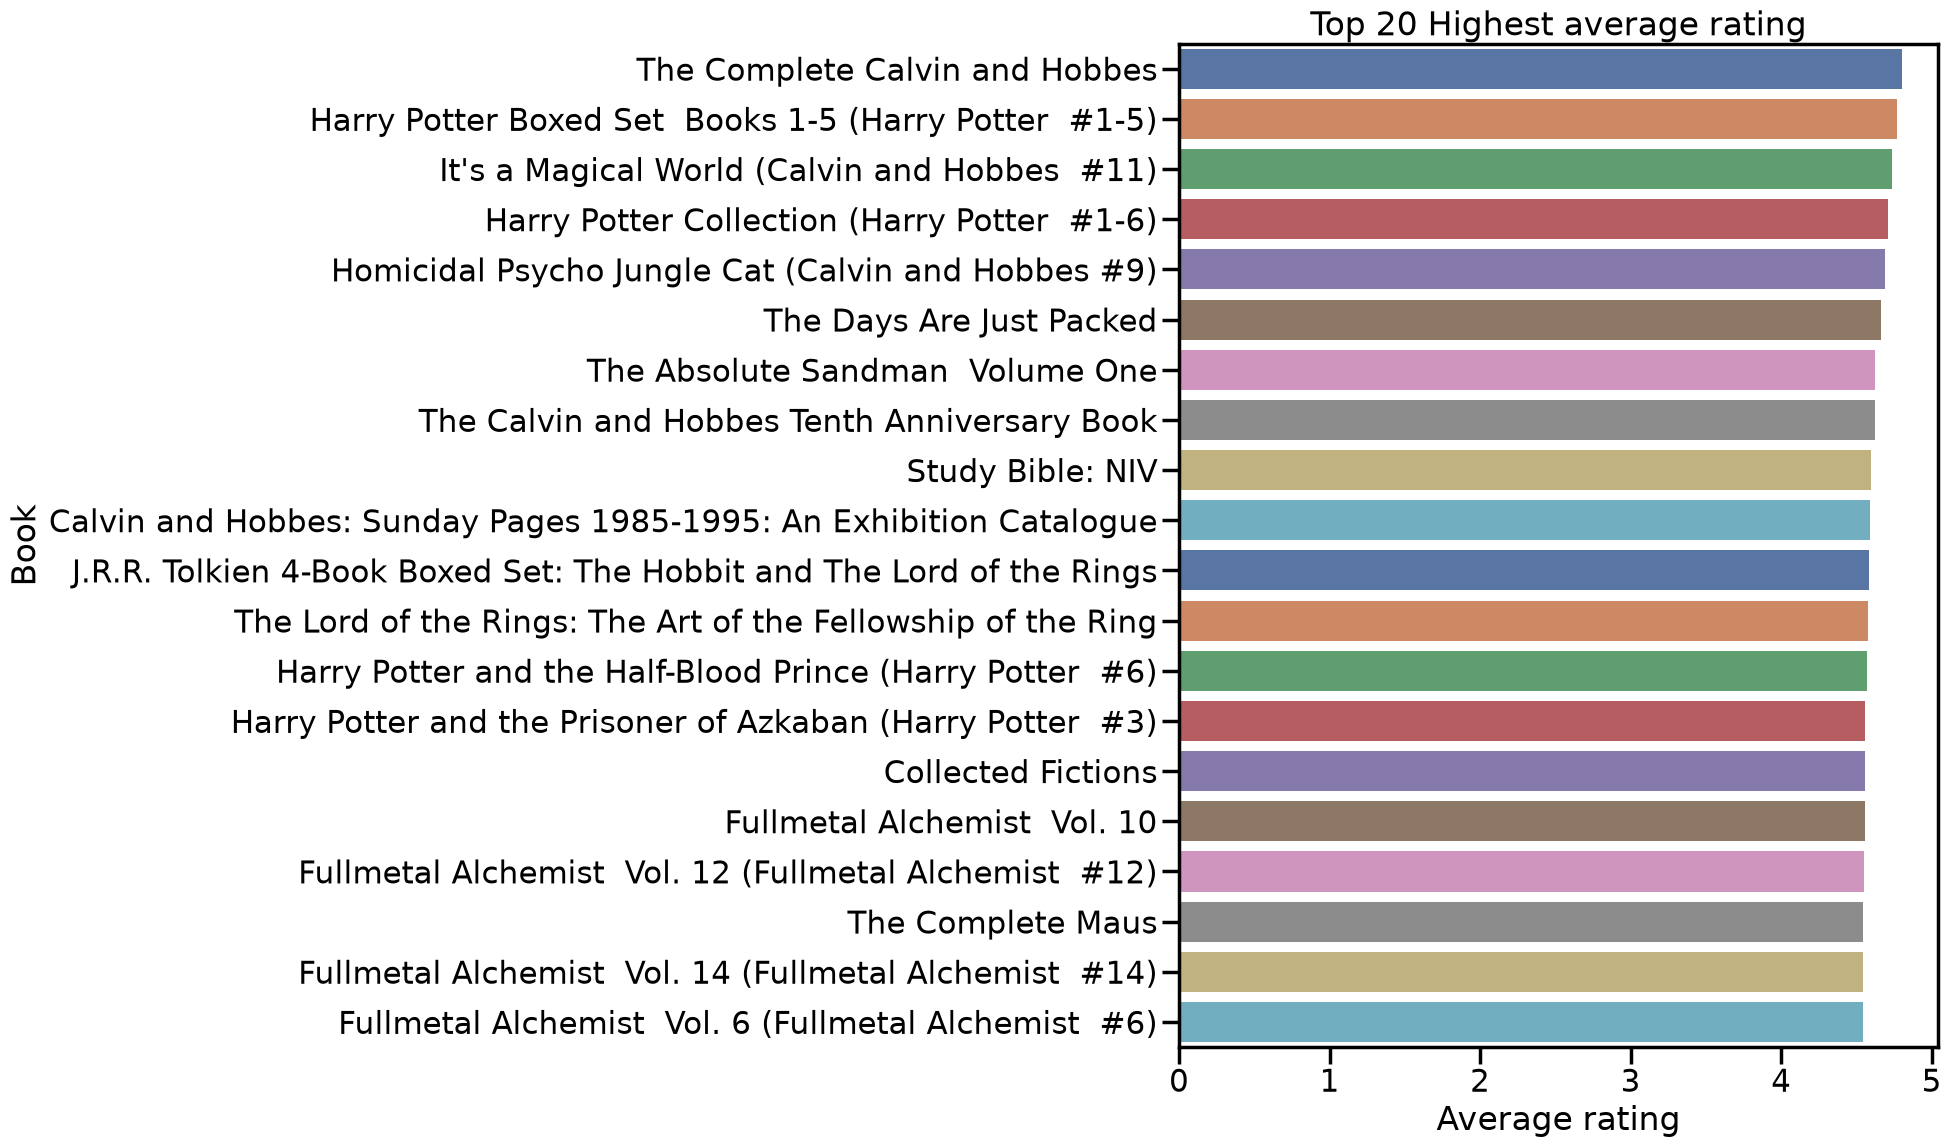

In [18]:
sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    y=top_books["title"],
    x=top_books["bayesian_avg"],
    palette="deep",
    hue=top_books["title"].values,
)
plt.title("Top 20 Highest average rating")
plt.xlabel("Average rating")
plt.ylabel("Book")
plt.tight_layout()
plt.show()

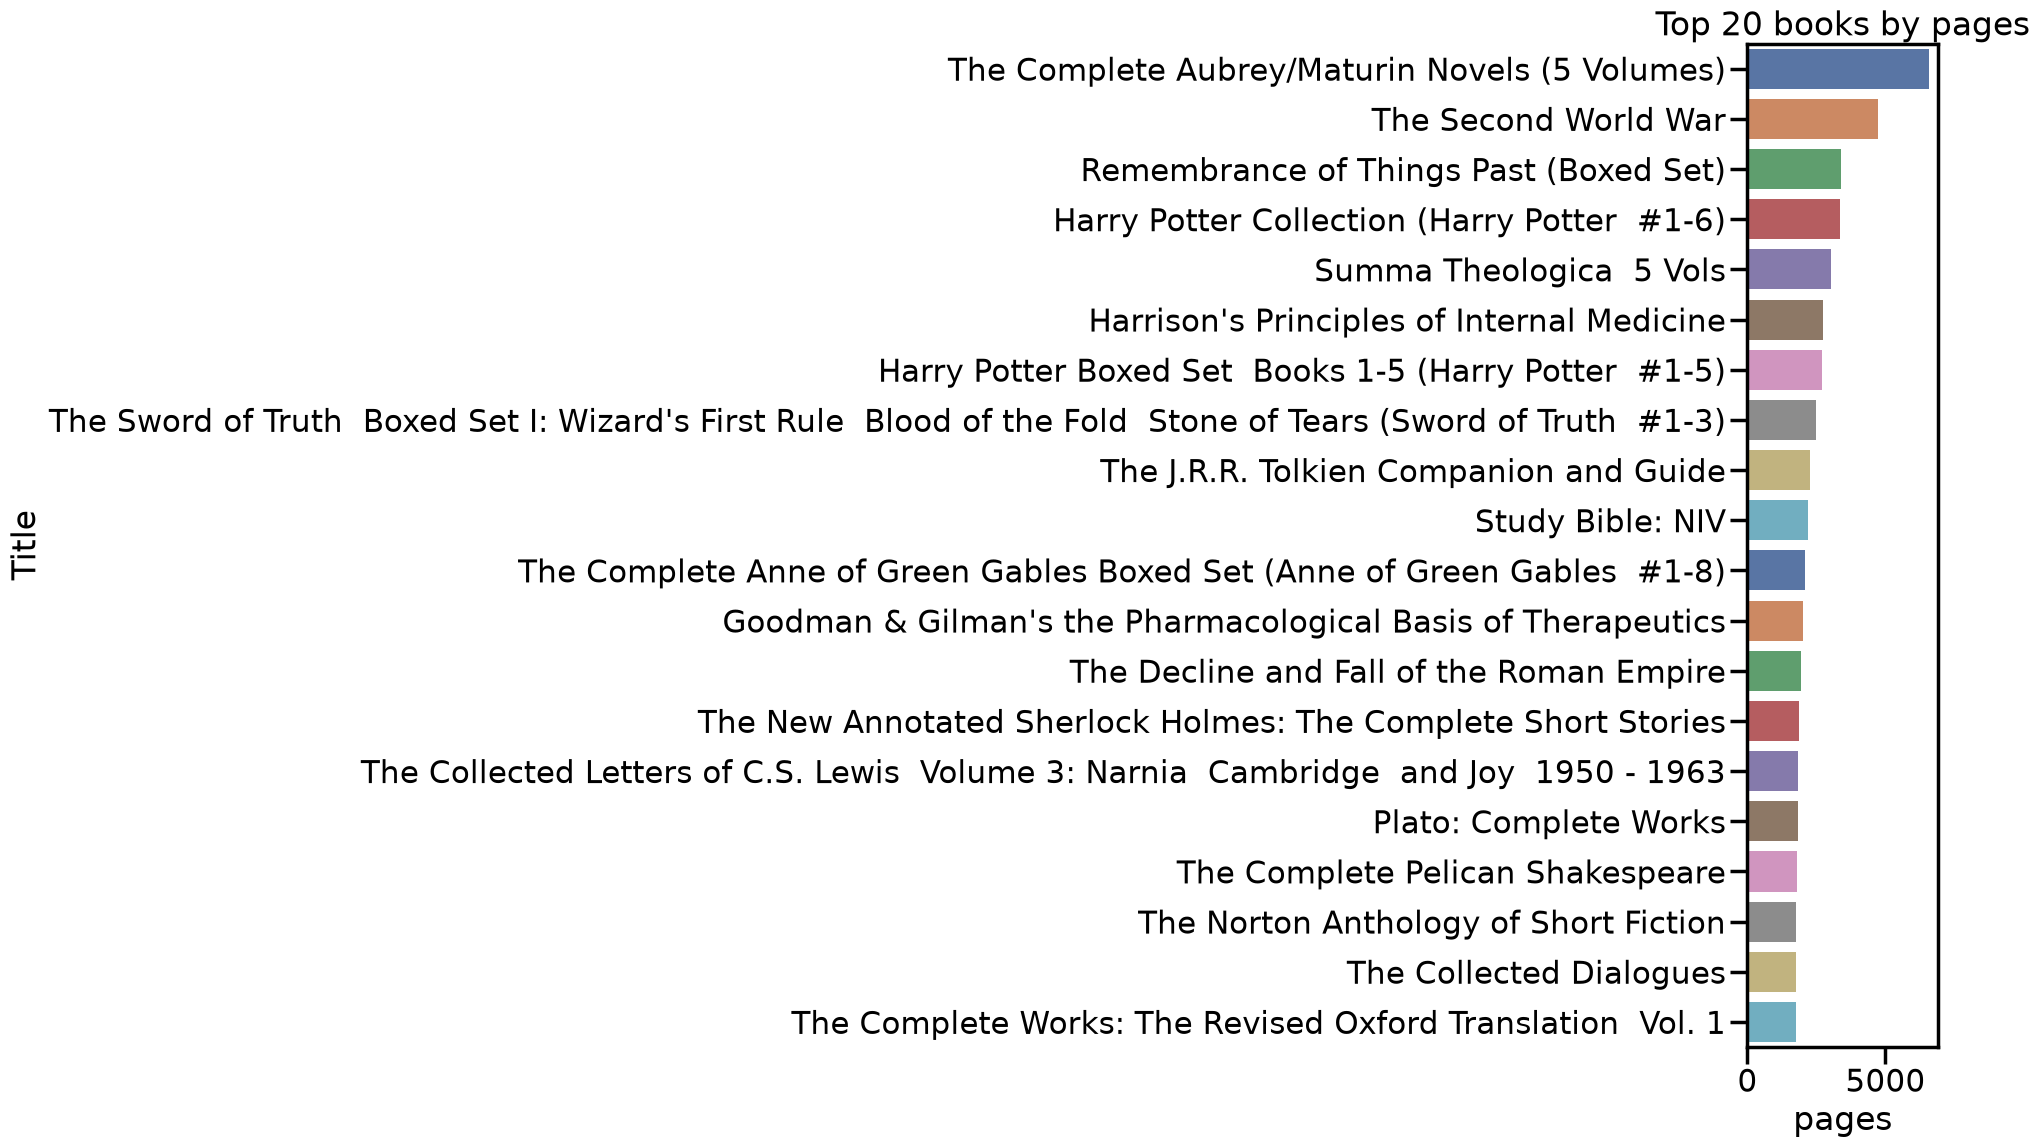

In [22]:
top_pages = df.nlargest(20, "num_pages")

sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    x=top_pages["num_pages"].values,
    y=top_pages["title"].values,
    palette="deep",
    hue=top_pages["title"].values,
)
plt.title("Top 20 books by pages")
plt.xlabel("pages")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

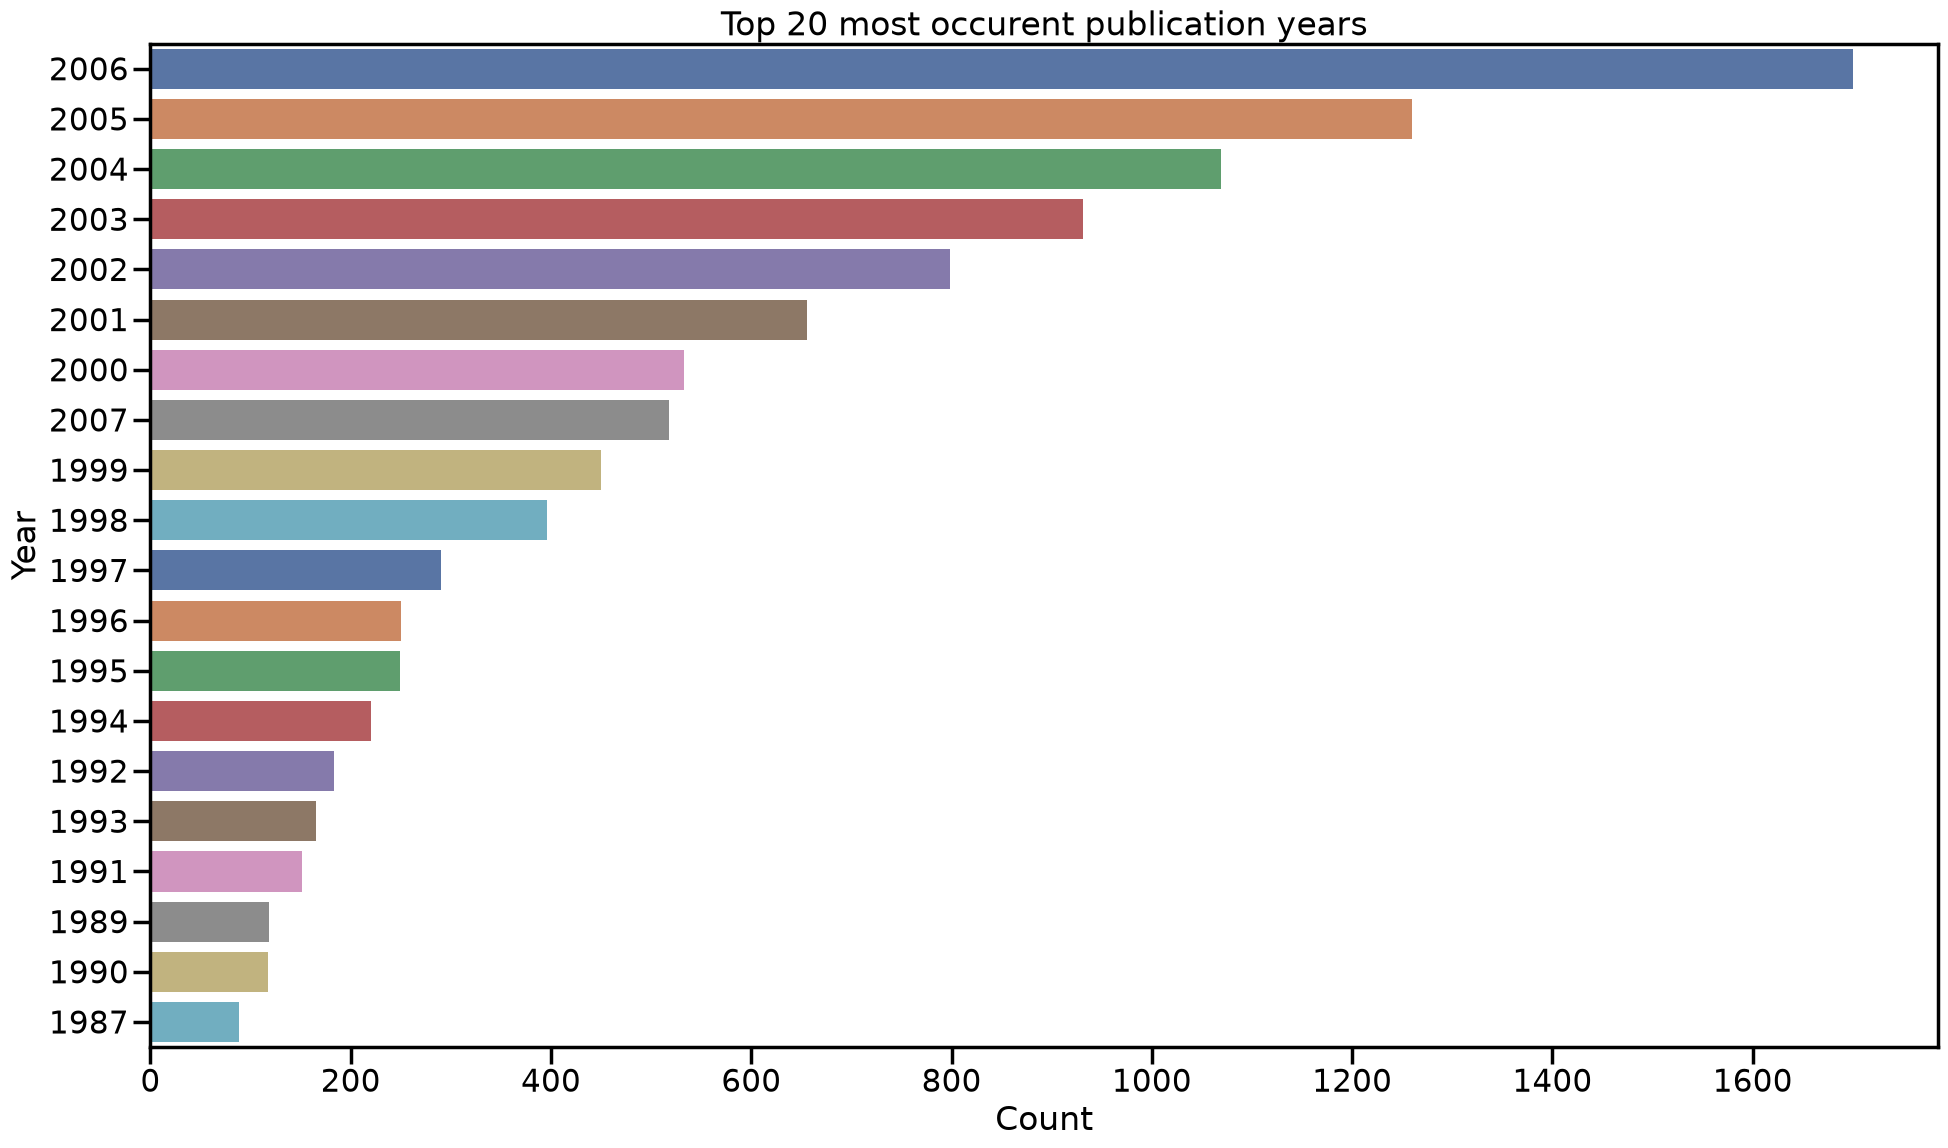

In [35]:
top_year = (pd.to_datetime(df['publication_date'], errors='coerce').dt.year.dropna().astype(int).value_counts()[:20]).sort_values(ascending=False)
top_year.index = top_year.index.astype(str)
sns.set_context("poster")
plt.figure(figsize=(20, 12))
sns.barplot(
    x=top_year.values, y=top_year.index, palette="deep", hue=top_year.index
)
plt.title("Top 20 most occurent publication years")
plt.xlabel("Count")
plt.ylabel("Year")
plt.tight_layout()
plt.show()




